## Preperation

In [7]:
import os
import torch
import torch.nn as nn
from Model import EEGModel
from Data import EEG0012017DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [16]:
DATA_PATH = '.\\RawDataset\\'
CACHE_PATH = '.\\Dataset\\'
MODEL_PATH = '.\\Models\\'

CRITERION = nn.CrossEntropyLoss()
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_ARCHITECTURES = ['EEGNet', 'DeepConvNet', 'ShallowFBCSPNet']

SUBJECT_COUNT = 15
LEARNING_RATE = 0.01
P_LEARNING_RATE = 0.02
BATCH_SIZE = 8
P_BATCH_SIZE = 16
EPOCH_NUM = 25
P_EPOCH_NUM = 20
RANDOM_SEED = 42
SPLIT = (0.8, 0.1, 0.1)

## Evaluation

In [9]:
def plot_learning_curves(train_losses, val_losses, title_exp='Loss'):
    """
    Plots the training and validation loss curves over epochs.
    
    Args:
        train_losses (list of floats): Loss values for the training set per epoch.
        val_losses (list of floats): Loss values for the validation set per epoch.
        save_path (str, optional): If provided, saves the plot to this file path.
    """
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, 'b-', label='Training Loss')
    plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
    
    plt.title(f'Training and Validation {title_exp}', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    
    # Force x-axis to use integer ticks for epochs
    plt.xticks(epochs) 
    
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)

    plt.show()

In [10]:
def plot_confusion_matrix(model, data_loader, class_names, title='Confusion Matrix'):
    """
    Plot confusion matrix for a PyTorch classification model.

    Parameters
    ----------
    model : EEGModel
        Your wrapper model containing the PyTorch model.
    data_loader : DataLoader
        DataLoader used for evaluation (e.g. test_loader).
    class_names : list
        Names of the target classes.
    title : str
        Plot title.
    """

    model.model.eval()

    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for X, y in data_loader:
            X = X.to(model.device)
            y = y.to(model.device)

            outputs = model.model(X)

            # For multi-class classification
            predictions = torch.argmax(outputs, dim=1)

            all_targets.extend(y.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    all_targets = np.array(all_targets)
    all_predictions = np.array(all_predictions)

    cm = confusion_matrix(
        all_targets,
        all_predictions,
        labels=np.arange(len(class_names))
    )

    fig, ax = plt.subplots(figsize=(8, 7))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(
        ax=ax,
        cmap='Blues',
        values_format='d',
        colorbar=True
    )

    ax.set_title(title)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    plt.tight_layout()
    plt.show()

    return cm

## DataLoading

In [11]:
data_loader_factory = EEG0012017DataLoader(
    data_path=DATA_PATH, 
    cache_path=CACHE_PATH, 
    batch_size=BATCH_SIZE,
    split_ratios=SPLIT
)

classes = data_loader_factory.get_class_names()
print(f"Target Classes: {classes}")

Target Classes: ['Elbow Flexion', 'Elbow Extension', 'Supination', 'Pronation', 'Hand Open', 'Hand Close', 'Rest']


## Basic Training 


------ Setting up training for Subject 1 ------
Loading Subject 1 from cache...
Normalizing data based on training set statistics...
Selected Architecture: EEGNet
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 8, 61, 769]             512
       BatchNorm2d-2           [-1, 8, 61, 769]              16
            Conv2d-3           [-1, 16, 1, 769]             976
       BatchNorm2d-4           [-1, 16, 1, 769]              32
               ELU-5           [-1, 16, 1, 769]               0
         AvgPool2d-6           [-1, 16, 1, 192]               0
           Dropout-7           [-1, 16, 1, 192]               0
            Conv2d-8           [-1, 16, 1, 192]             256
            Conv2d-9           [-1, 16, 1, 192]             256
      BatchNorm2d-10           [-1, 16, 1, 192]              32
              ELU-11           [-1, 16, 1, 192]               0
   

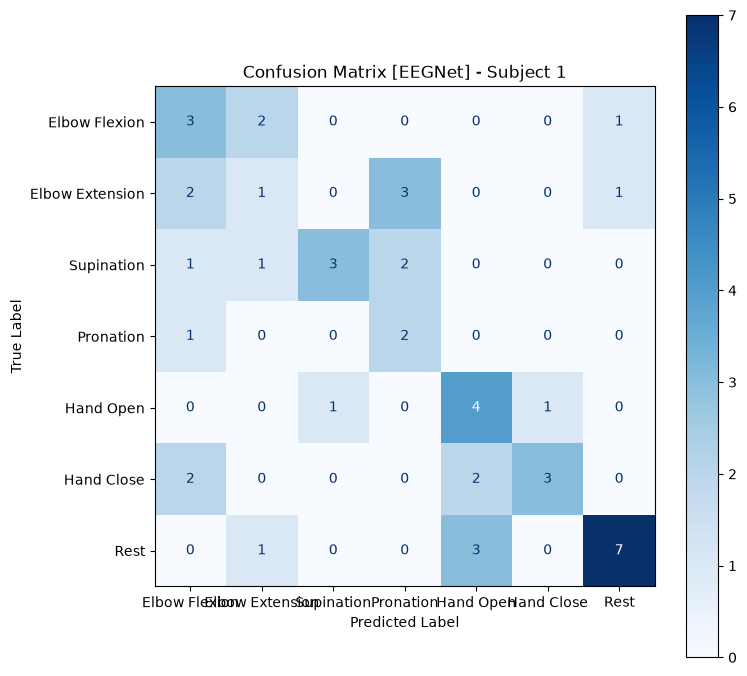

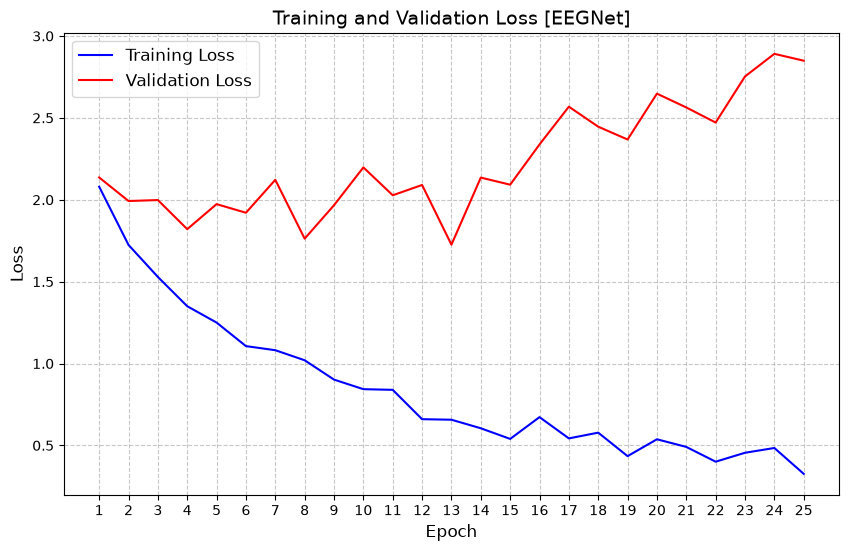

Selected Architecture: DeepConvNet
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 25, 61, 760]             250
            Conv2d-2           [-1, 25, 1, 760]          38,125
       BatchNorm2d-3           [-1, 25, 1, 760]              50
               ELU-4           [-1, 25, 1, 760]               0
         MaxPool2d-5           [-1, 25, 1, 253]               0
           Dropout-6           [-1, 25, 1, 253]               0
            Conv2d-7           [-1, 50, 1, 244]          12,500
       BatchNorm2d-8           [-1, 50, 1, 244]             100
               ELU-9           [-1, 50, 1, 244]               0
        MaxPool2d-10            [-1, 50, 1, 81]               0
          Dropout-11            [-1, 50, 1, 81]               0
           Conv2d-12           [-1, 100, 1, 72]          50,000
      BatchNorm2d-13           [-1, 100, 1, 72]             200
    

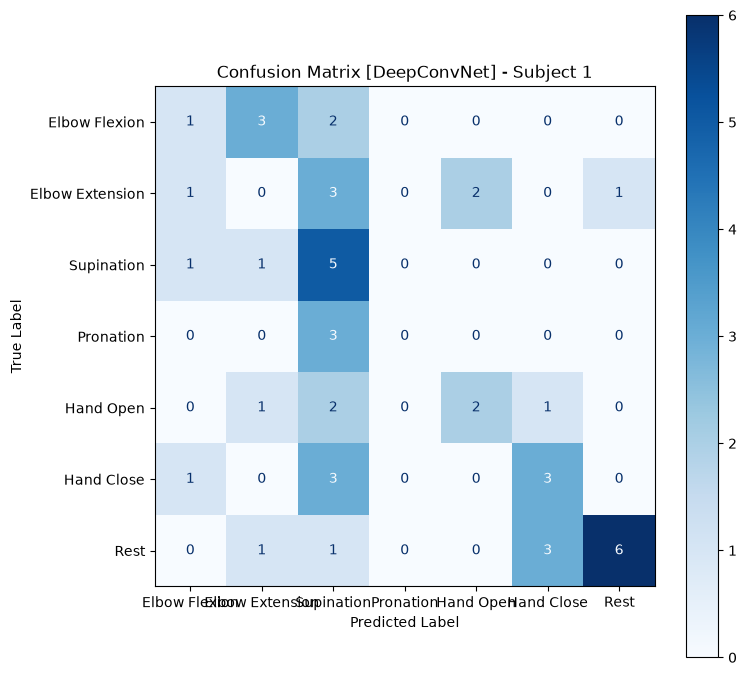

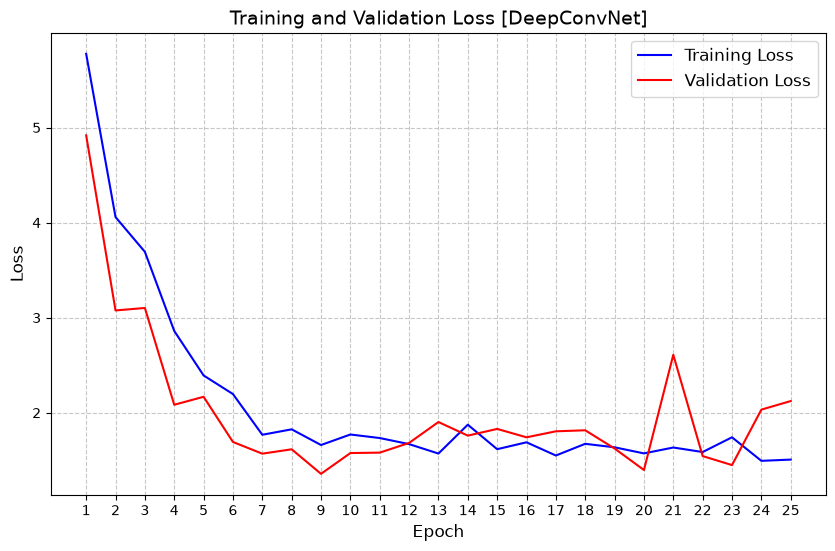

Selected Architecture: ShallowFBCSPNet
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 40, 61, 745]           1,000
            Conv2d-2           [-1, 40, 1, 745]          97,600
       BatchNorm2d-3           [-1, 40, 1, 745]              80
        Expression-4           [-1, 40, 1, 745]               0
         AvgPool2d-5            [-1, 40, 1, 45]               0
        Expression-6            [-1, 40, 1, 45]               0
           Dropout-7            [-1, 40, 1, 45]               0
           Flatten-8                 [-1, 1800]               0
            Linear-9                    [-1, 7]          12,607
Total params: 111,287
Trainable params: 111,287
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.18
Forward/backward pass size (MB): 14.61
Params size (MB): 0.42
Estimated Total Size (MB): 15.21
--

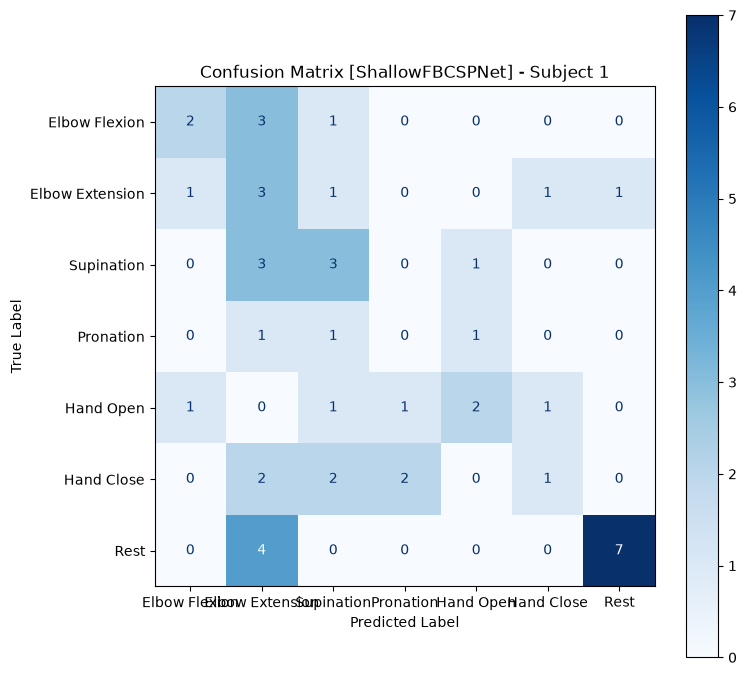

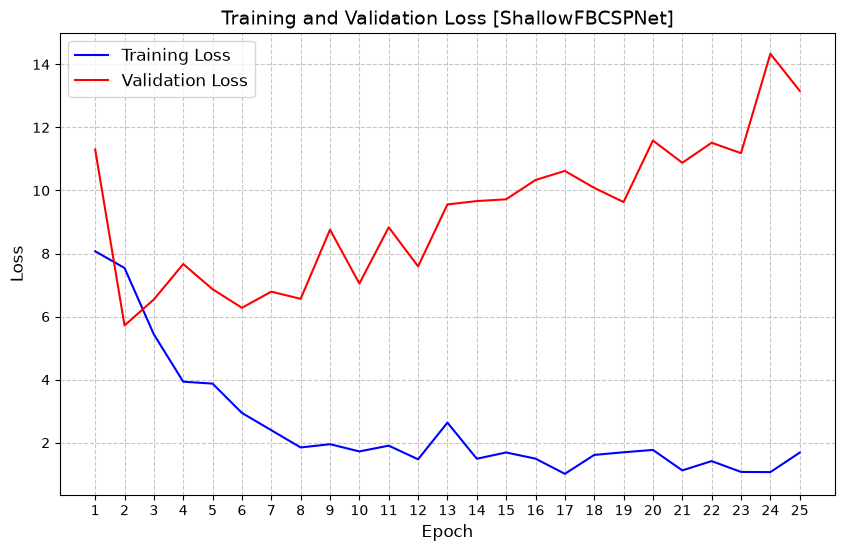

Finished training Subject 1.


In [ ]:
subject_id = 1
print(f"\n------ Setting up training for Subject {subject_id} ------")
train_loader, val_loader, test_loader = data_loader_factory.get_dataloaders(subject=subject_id, random_seed=RANDOM_SEED)


for architecture in MODEL_ARCHITECTURES:
    print('Selected Architecture:', architecture)
    model = EEGModel(
        criterion=CRITERION,
        learning_rate=LEARNING_RATE,
        architecture_key=architecture,
        random_seed=RANDOM_SEED,
        device=DEVICE
    )
    model.model_summary()
    train_loss, val_loss = [], []
    best_val_accuracy = -float('inf')
    best_epoch = 0
    best_model_path = str(MODEL_PATH + f'Subject {subject_id}\\{architecture}_{LEARNING_RATE}_{EPOCH_NUM}.pth')

    for epoch in range(EPOCH_NUM):
        t_loss, v_loss = model.train_one_epoch(train_loader, val_loader)
        train_loss.append(t_loss)
        val_loss.append(v_loss)
        train_acc = model.evaluate_accuracy(train_loader)
        val_acc = model.evaluate_accuracy(val_loader)
        print(
            f'Epoch#{epoch + 1} ====',
            f'train acc: {train_acc:.4f}, train loss: {t_loss:.4f} ====',
            f'val acc: {val_acc:.4f}, val loss: {v_loss:.4f}'
        )

        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            best_epoch = epoch + 1
            model.save_model(best_model_path)
            print(f'>>> Best model saved! Val Accuracy: {best_val_accuracy:.4f}% (Epoch {best_epoch})')

    print('\nBest Model:')
    print(f'\tEpoch: {best_epoch}')
    print(f'\tValidation Accuracy: {best_val_accuracy:.4f}%')
    print(f'\tSaved to: {best_model_path}')

    model.load_model(best_model_path)

    print('\nModel Final Accuracy (Best Validation Model):')
    print('\tTrain:', model.evaluate_accuracy(train_loader))
    print('\tTest:', model.evaluate_accuracy(test_loader))
    print('\tValidation:', model.evaluate_accuracy(val_loader))

    plot_confusion_matrix(
    model=model,
    data_loader=test_loader,
    class_names=classes,
    title=f'Confusion Matrix [{architecture}] - Subject {subject_id}')
    plot_learning_curves(train_losses=train_loss, val_losses=val_loss, title_exp=f'Loss [{architecture}]')

print(f"Finished training Subject {subject_id}.")

## Pretraining


------ Setting up training for ALL Subjects ------
Loading Subject 1 from cache...
Normalizing data based on training set statistics...
Loading Subject 2 from cache...
Normalizing data based on training set statistics...
Loading Subject 3 from cache...
Normalizing data based on training set statistics...
Loading Subject 4 from cache...
Normalizing data based on training set statistics...
Loading Subject 5 from cache...
Normalizing data based on training set statistics...
Loading Subject 6 from cache...
Normalizing data based on training set statistics...
Loading Subject 7 from cache...
Normalizing data based on training set statistics...
Loading Subject 8 from cache...
Normalizing data based on training set statistics...
Loading Subject 9 from cache...
Normalizing data based on training set statistics...
Loading Subject 10 from cache...
Normalizing data based on training set statistics...
Loading Subject 11 from cache...
Normalizing data based on training set statistics...
Loading Sub

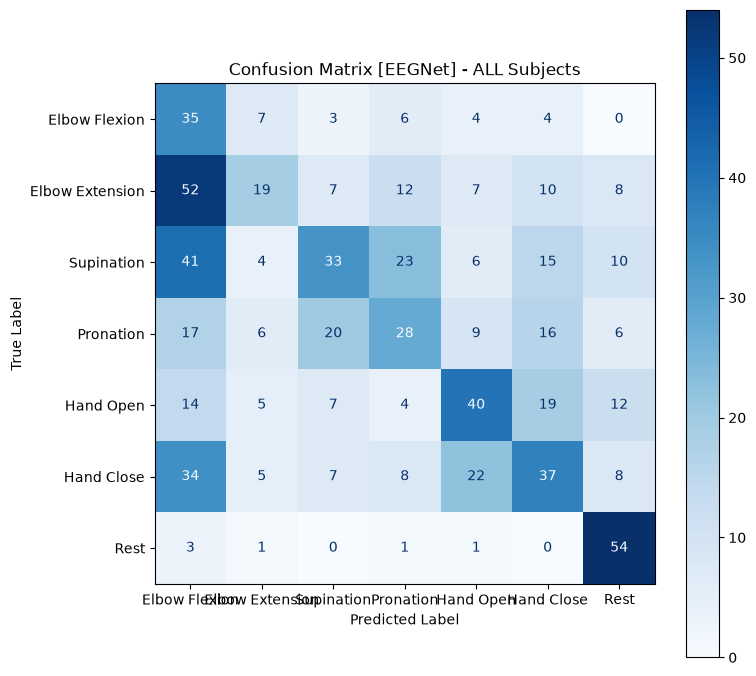

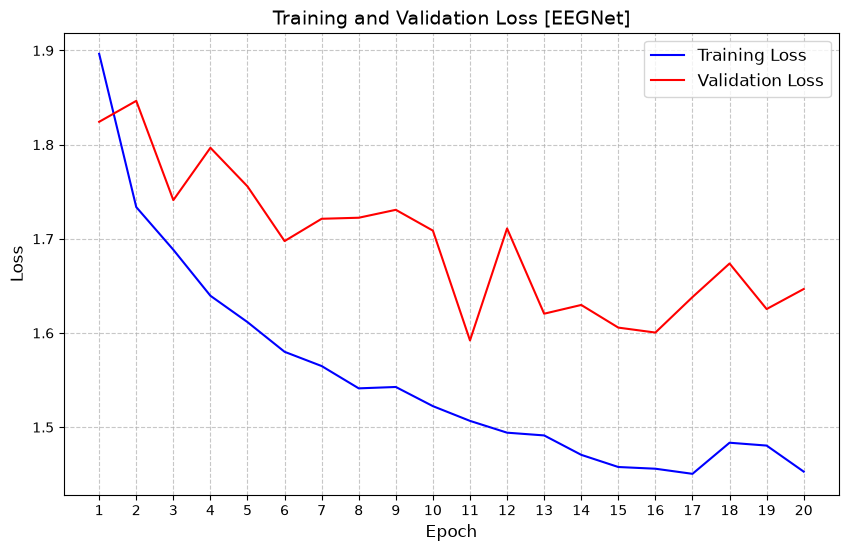

Selected Architecture: DeepConvNet
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 25, 61, 760]             250
            Conv2d-2           [-1, 25, 1, 760]          38,125
       BatchNorm2d-3           [-1, 25, 1, 760]              50
               ELU-4           [-1, 25, 1, 760]               0
         MaxPool2d-5           [-1, 25, 1, 253]               0
           Dropout-6           [-1, 25, 1, 253]               0
            Conv2d-7           [-1, 50, 1, 244]          12,500
       BatchNorm2d-8           [-1, 50, 1, 244]             100
               ELU-9           [-1, 50, 1, 244]               0
        MaxPool2d-10            [-1, 50, 1, 81]               0
          Dropout-11            [-1, 50, 1, 81]               0
           Conv2d-12           [-1, 100, 1, 72]          50,000
      BatchNorm2d-13           [-1, 100, 1, 72]             200
    

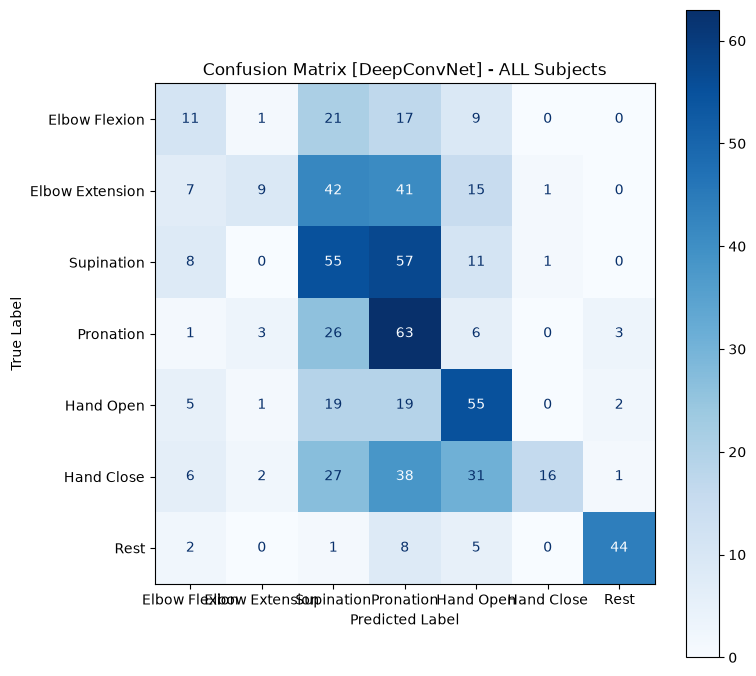

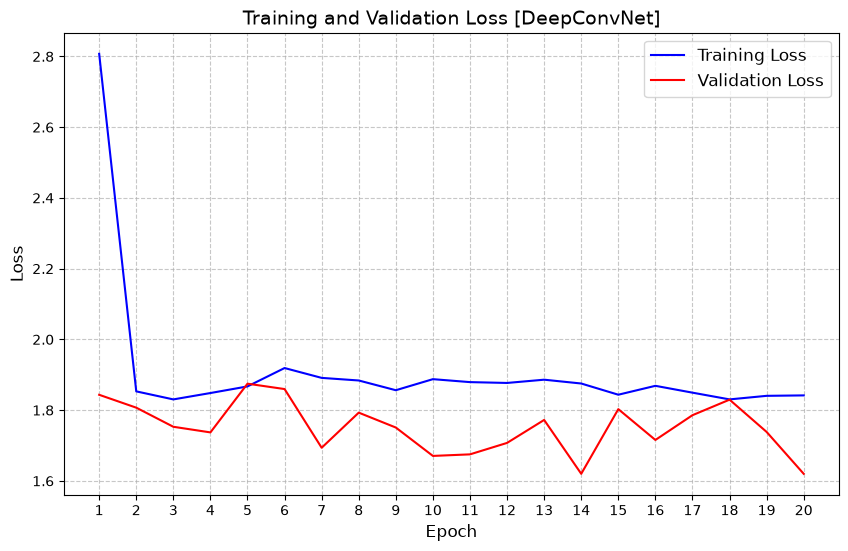

Selected Architecture: ShallowFBCSPNet
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 40, 61, 745]           1,000
            Conv2d-2           [-1, 40, 1, 745]          97,600
       BatchNorm2d-3           [-1, 40, 1, 745]              80
        Expression-4           [-1, 40, 1, 745]               0
         AvgPool2d-5            [-1, 40, 1, 45]               0
        Expression-6            [-1, 40, 1, 45]               0
           Dropout-7            [-1, 40, 1, 45]               0
           Flatten-8                 [-1, 1800]               0
            Linear-9                    [-1, 7]          12,607
Total params: 111,287
Trainable params: 111,287
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.18
Forward/backward pass size (MB): 14.61
Params size (MB): 0.42
Estimated Total Size (MB): 15.21
--

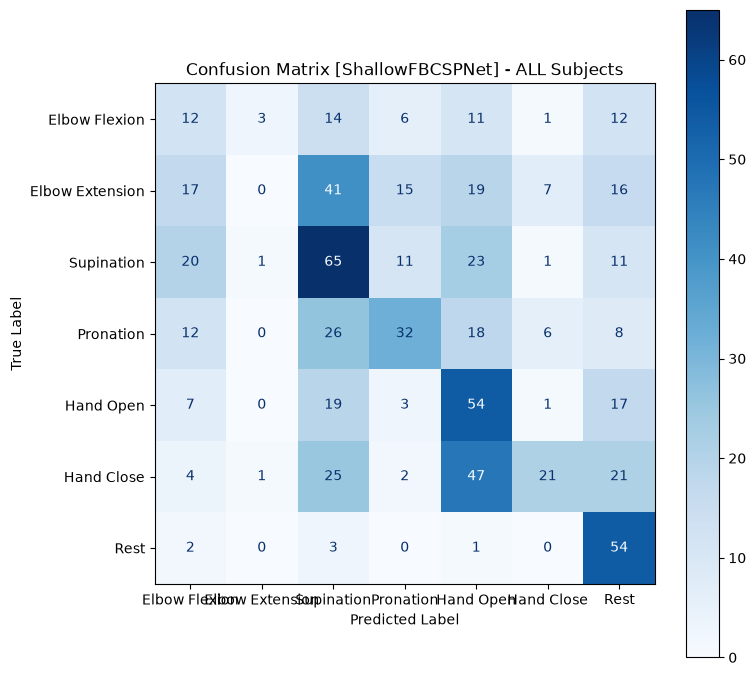

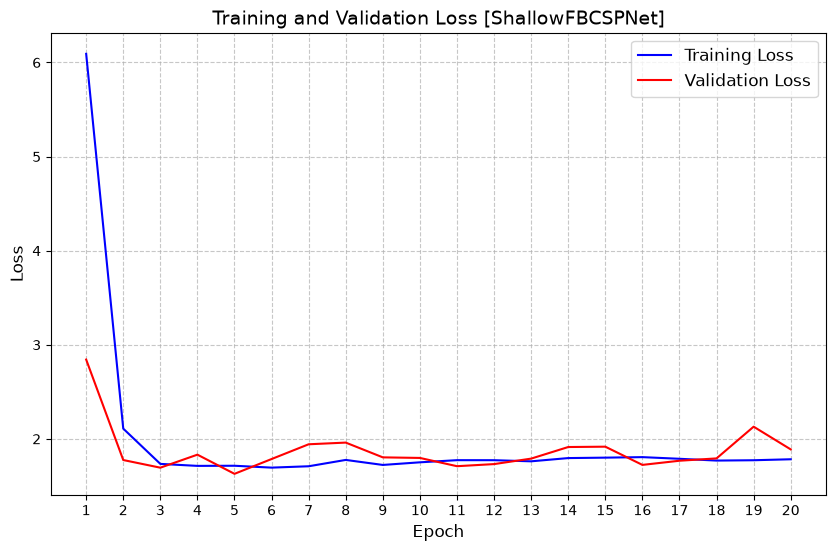

Finished training.


In [18]:
print(f"\n------ Setting up training for ALL Subjects ------")
subjects=[i + 1 for i in range(SUBJECT_COUNT)]
full_train_loader = data_loader_factory.combined_dataloaders(subjects=subjects, batch_size=P_BATCH_SIZE, random_seed=RANDOM_SEED)
full_val_loader = data_loader_factory.combined_dataloaders(subjects=subjects, batch_size=P_BATCH_SIZE, random_seed=RANDOM_SEED, train=False)


for architecture in MODEL_ARCHITECTURES:
    print('Selected Architecture:', architecture)
    model = EEGModel(
        criterion=CRITERION,
        learning_rate=P_LEARNING_RATE,
        architecture_key=architecture,
        random_seed=RANDOM_SEED,
        device=DEVICE
    )
    model.model_summary()
    train_loss, val_loss = [], []
    model_path = str(MODEL_PATH + f'Pretrained\\{architecture}_{P_LEARNING_RATE}_{P_EPOCH_NUM}.pth')

    for epoch in range(P_EPOCH_NUM):
        t_loss, v_loss = model.train_one_epoch(full_train_loader, full_val_loader)
        train_loss.append(t_loss)
        val_loss.append(v_loss)
        train_acc = model.evaluate_accuracy(full_train_loader)
        val_acc = model.evaluate_accuracy(full_val_loader)
        print(
            f'Epoch#{epoch + 1} ====',
            f'train acc: {train_acc:.4f}, train loss: {t_loss:.4f} ====',
            f'val acc: {val_acc:.4f}, val loss: {v_loss:.4f}'
        )

    model.save_model(model_path)

    print('\nModel Final Accuracy:')
    print('\tTrain:', model.evaluate_accuracy(full_train_loader))
    print('\tValidation:', model.evaluate_accuracy(full_val_loader))

    plot_confusion_matrix(
        model=model,
        data_loader=full_val_loader,
        class_names=classes,
        title=f'Confusion Matrix [{architecture}] - ALL Subjects'
    )
    plot_learning_curves(train_losses=train_loss, val_losses=val_loss, title_exp=f'Loss [{architecture}]')

print(f"Finished training.")


------ Setting up training for Subject 1 ------
Loading Subject 1 from cache...
Normalizing data based on training set statistics...
Selected Architecture: EEGNet
Model loaded successfully from .\Models\Pretrained\EEGNet_0.02_20.pth
Epoch#1 ==== train acc: 57.1816, train loss: 1.5033 ==== val acc: 39.1304, val loss: 1.5714
Model saved successfully to .\Models\Subject 1\Finetuned_EEGNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 39.1304% (Epoch 1)
Epoch#2 ==== train acc: 62.6016, train loss: 1.3165 ==== val acc: 39.1304, val loss: 1.5219
Epoch#3 ==== train acc: 70.1897, train loss: 1.1559 ==== val acc: 36.9565, val loss: 1.4865
Epoch#4 ==== train acc: 73.7127, train loss: 1.0140 ==== val acc: 45.6522, val loss: 1.5344
Model saved successfully to .\Models\Subject 1\Finetuned_EEGNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 45.6522% (Epoch 4)
Epoch#5 ==== train acc: 79.4038, train loss: 0.8985 ==== val acc: 41.3043, val loss: 1.7997
Epoch#6 ==== train acc: 84.2818, train loss:

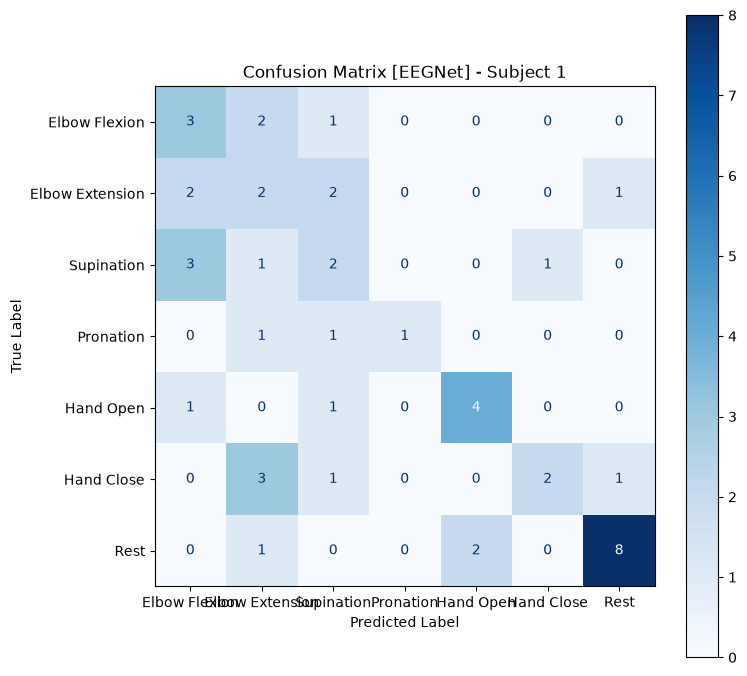

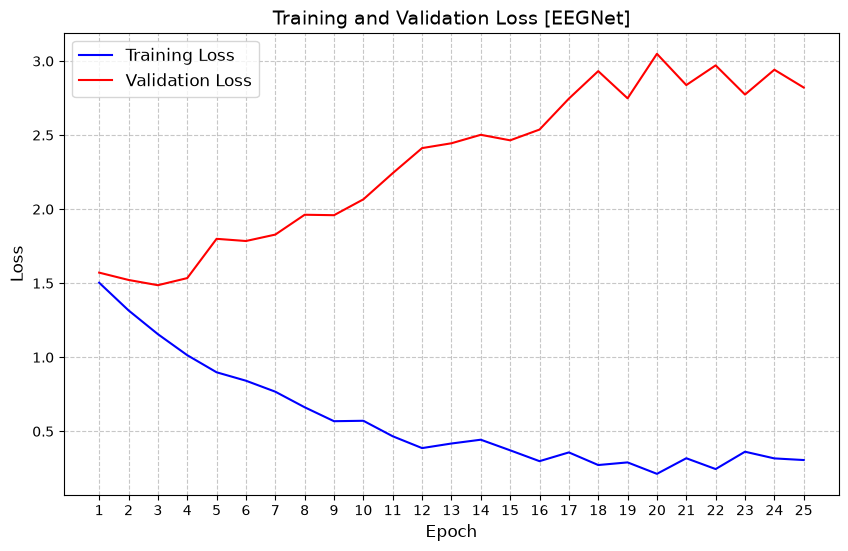

Selected Architecture: DeepConvNet
Model loaded successfully from .\Models\Pretrained\DeepConvNet_0.02_20.pth
Epoch#1 ==== train acc: 49.0515, train loss: 1.8905 ==== val acc: 50.0000, val loss: 1.4787
Model saved successfully to .\Models\Subject 1\Finetuned_DeepConvNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 50.0000% (Epoch 1)
Epoch#2 ==== train acc: 65.0407, train loss: 1.6306 ==== val acc: 60.8696, val loss: 1.3632
Model saved successfully to .\Models\Subject 1\Finetuned_DeepConvNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 60.8696% (Epoch 2)
Epoch#3 ==== train acc: 65.5827, train loss: 1.3594 ==== val acc: 52.1739, val loss: 1.3871
Epoch#4 ==== train acc: 59.6206, train loss: 1.3335 ==== val acc: 41.3043, val loss: 1.6815
Epoch#5 ==== train acc: 64.4986, train loss: 1.3255 ==== val acc: 50.0000, val loss: 1.2961
Epoch#6 ==== train acc: 78.0488, train loss: 1.1230 ==== val acc: 52.1739, val loss: 1.3289
Epoch#7 ==== train acc: 69.6477, train loss: 1.1272 ==== val acc: 

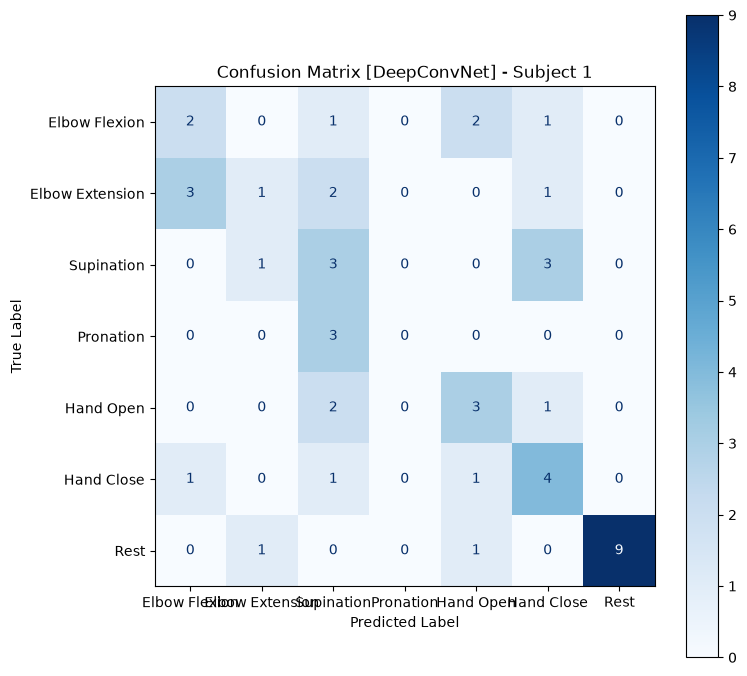

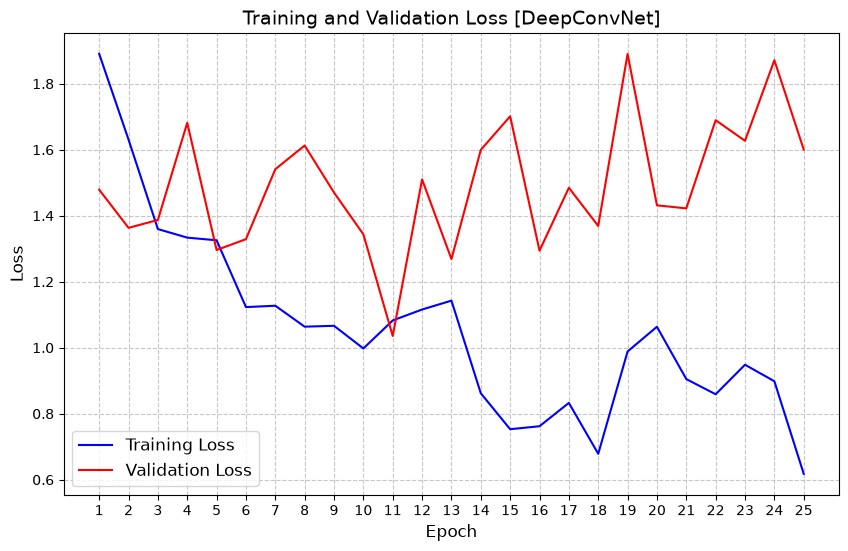

Selected Architecture: ShallowFBCSPNet
Model loaded successfully from .\Models\Pretrained\ShallowFBCSPNet_0.02_20.pth
Epoch#1 ==== train acc: 68.5637, train loss: 1.6270 ==== val acc: 41.3043, val loss: 1.6554
Model saved successfully to .\Models\Subject 1\Finetuned_ShallowFBCSPNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 41.3043% (Epoch 1)
Epoch#2 ==== train acc: 73.4417, train loss: 1.2863 ==== val acc: 47.8261, val loss: 1.4256
Model saved successfully to .\Models\Subject 1\Finetuned_ShallowFBCSPNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 47.8261% (Epoch 2)
Epoch#3 ==== train acc: 82.1138, train loss: 1.1247 ==== val acc: 52.1739, val loss: 1.4162
Model saved successfully to .\Models\Subject 1\Finetuned_ShallowFBCSPNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 52.1739% (Epoch 3)
Epoch#4 ==== train acc: 72.8997, train loss: 0.9635 ==== val acc: 41.3043, val loss: 1.6767
Epoch#5 ==== train acc: 92.4119, train loss: 0.8273 ==== val acc: 54.3478, val loss: 1.5112
Mo

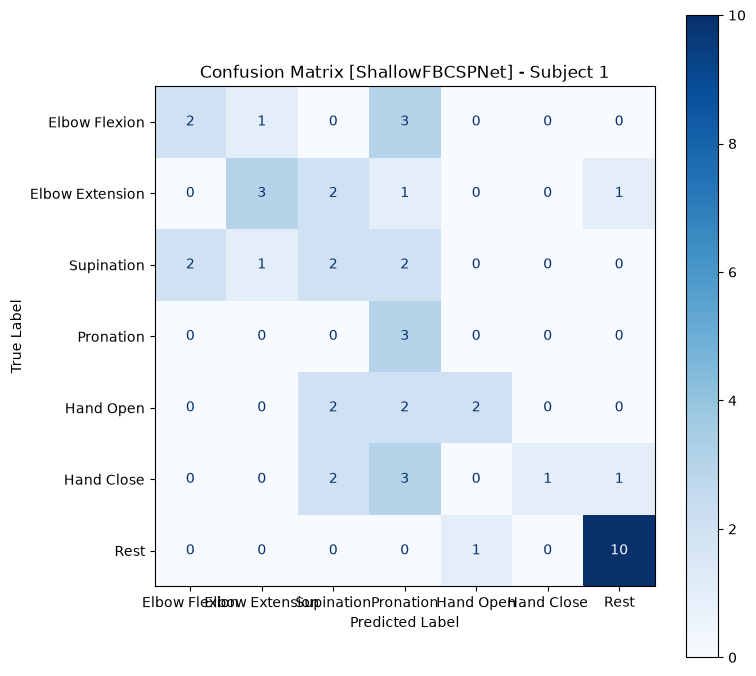

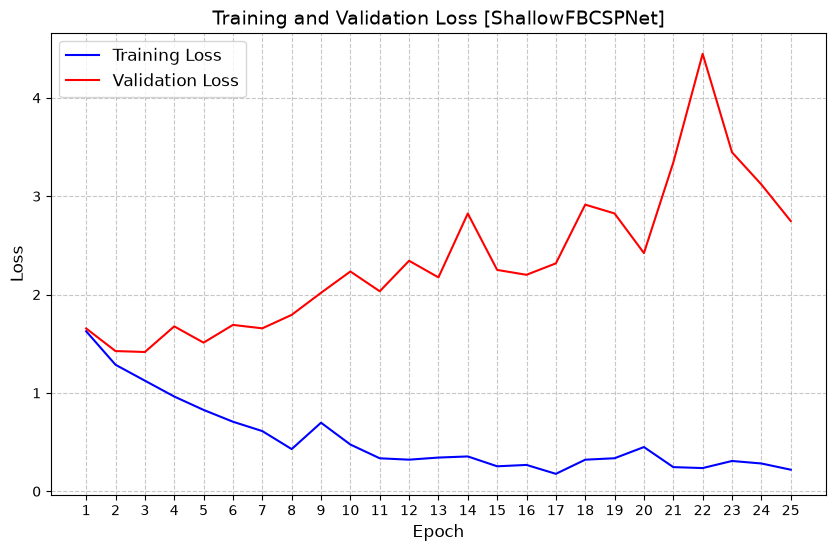

Finished training Subject 1.


In [19]:
subject_id = 1
print(f"\n------ Setting up training for Subject {subject_id} ------")
train_loader, val_loader, test_loader = data_loader_factory.get_dataloaders(subject=subject_id, random_seed=RANDOM_SEED)


for architecture in MODEL_ARCHITECTURES:
    print('Selected Architecture:', architecture)
    model = EEGModel(
        criterion=CRITERION,
        learning_rate=LEARNING_RATE,
        architecture_key=architecture,
        random_seed=RANDOM_SEED,
        device=DEVICE
    )
    pretrained_model_path = str(MODEL_PATH + f'Pretrained\\{architecture}_{P_LEARNING_RATE}_{P_EPOCH_NUM}.pth')
    model.load_model(pretrained_model_path)
    train_loss, val_loss = [], []
    best_val_accuracy = -float('inf')
    best_epoch = 0
    best_model_path = str(MODEL_PATH + f'Subject {subject_id}\\Finetuned_{architecture}_{LEARNING_RATE}_{EPOCH_NUM}.pth')

    for epoch in range(EPOCH_NUM):
        t_loss, v_loss = model.train_one_epoch(train_loader, val_loader)
        train_loss.append(t_loss)
        val_loss.append(v_loss)
        train_acc = model.evaluate_accuracy(train_loader)
        val_acc = model.evaluate_accuracy(val_loader)
        print(
            f'Epoch#{epoch + 1} ====',
            f'train acc: {train_acc:.4f}, train loss: {t_loss:.4f} ====',
            f'val acc: {val_acc:.4f}, val loss: {v_loss:.4f}'
        )

        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            best_epoch = epoch + 1
            model.save_model(best_model_path)
            print(f'>>> Best model saved! Val Accuracy: {best_val_accuracy:.4f}% (Epoch {best_epoch})')

    print('\nBest Model:')
    print(f'\tEpoch: {best_epoch}')
    print(f'\tValidation Accuracy: {best_val_accuracy:.4f}%')
    print(f'\tSaved to: {best_model_path}')

    model.load_model(best_model_path)

    print('\nModel Final Accuracy (Best Validation Model):')
    print('\tTrain:', model.evaluate_accuracy(train_loader))
    print('\tTest:', model.evaluate_accuracy(test_loader))
    print('\tValidation:', model.evaluate_accuracy(val_loader))

    plot_confusion_matrix(
    model=model,
    data_loader=test_loader,
    class_names=classes,
    title=f'Confusion Matrix [{architecture}] - Subject {subject_id}')
    plot_learning_curves(train_losses=train_loss, val_losses=val_loss, title_exp=f'Loss [{architecture}]')

print(f"Finished training Subject {subject_id}.")